In [8]:
import zipfile

with zipfile.ZipFile("experiments.zip", "r") as z:
    z.extractall(".")

In [6]:
!pwd
!ls -lh

/content
total 108M
-rw-r--r-- 1 root root 108M Jul 27 09:45 experiments.zip
drwxr-xr-x 1 root root 4.0K Jun  4 13:32 sample_data


# Experiment Analysis & Turn-On Curve Diagnostics
This notebook aggregates all trained neural network results from the `experiments/` directory. It parses the metadata (`config.json`) and the computed physics numbers (`metrics.json`) to create comparative summaries and publication-ready plots for the final report.


In [9]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# IF YOU WANT TO RUN WITH SEPEARTE SEEDS INSTEAF OF AVERAGE, CTRL+F THIS: "ChangeHereForSeed" AND CHANGE ALL NEEDED PLACES>.

EXPERIMENTS_DIR = r"experiments/config_batch6"

# Apply professional plotting styles for the report
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'figure.facecolor': 'white',
    'grid.linestyle': ':',
    'grid.alpha': 0.6
})

def load_all_experiments(base_dir="experiments"):
    """Crawls the experiments directory and collects configuration and evaluation metrics."""
    summary_data = []

    # Locate all subdirectories containing a metrics file
    # metrics_files = glob.glob(os.path.join(base_dir, "run_*", "metrics.json")) # ChangeHereForSeed use this instead of line after
    metrics_files = glob.glob(os.path.join(base_dir, "run_*", "metrics_averaged.json"))
    print(f"Found {len(metrics_files)} metrics files.")
    for m_path in metrics_files:
        run_dir = os.path.dirname(m_path)
        c_path = os.path.join(run_dir, "config.json")

        with open(m_path, 'r') as f:
            metrics = json.load(f)
        with open(c_path, 'r') as f:
            config = json.load(f)

        # Dynamically create the architecture string (e.g., [32, 16] becomes "32x16")
        hidden_layers = config.get("hidden_layers", [])
        architecture = "x".join(map(str, hidden_layers)) if hidden_layers else "Baseline"

        # Compile flat dictionary of parameters and primary metrics directly from JSON
        run_summary = {
            "run_id": os.path.basename(run_dir),
            "experiment_name": config.get("experiment_name"),
            "features": ", ".join(config.get("features_to_use", [])),
            # "learning_rate": config.get("learning_rate"),
            "learning_rate": config.get("learning_rate"),
            "batch_size": config.get("batch_size"),
            "architecture": architecture,
            "epochs": config.get("epochs"),
            "eff_at_0.5_FR": metrics["global_efficiency"].get("0.5%"),
            "eff_at_1.0_FR": metrics["global_efficiency"].get("1.0%"),
            "fd_midpoint": metrics["turn_on_curve"]["fermi_dirac_fit"].get("midpoint"),
            "fd_slope": metrics["turn_on_curve"]["fermi_dirac_fit"].get("slope"),
            "fd_plateau": metrics["turn_on_curve"]["fermi_dirac_fit"].get("plateau"),
            "fd_chi2_red": metrics["turn_on_curve"]["fermi_dirac_fit"].get("chi2_red"),
            "fd_p_value": metrics["turn_on_curve"]["fermi_dirac_fit"].get("p_value"),
            "path": run_dir,
            "seed": config.get("seed", 0)
        }
        summary_data.append(run_summary)

    return pd.DataFrame(summary_data)

# Load and display the master experiment table
df_experiments = load_all_experiments(base_dir=EXPERIMENTS_DIR)

# Only attempt to drop 'seed' and duplicates if the DataFrame is not empty
if not df_experiments.empty:
    df_experiments = df_experiments.drop('seed', axis=1).drop_duplicates(subset='experiment_name')
    df_experiments.sort_values(by="eff_at_0.5_FR", ascending=False)
else:
    print("No experiment data loaded. df_experiments is empty.")


Found 12 metrics files.


## Performance Summary Table
Below is the master compilation of all execution parameters alongside hard numerical results. We evaluate global signal efficiencies at tightly constrained background Fake Rates ($0.5\%$ and $1.0\%$), alongside the extracted Fermi-Dirac fit parameters for the 1D turn-on curves.

In [10]:
# Display select columns for clean reporting
# ChangeHereForSeed use the commented out line instead
# view_cols = ['experiment_name', 'seed', 'eff_at_0.5_FR', 'fd_midpoint', 'fd_slope', 'fd_plateau', 'fd_chi2_red', 'fd_p_value', 'learning_rate', 'batch_size', 'architecture', 'features', 'epochs']

view_cols = ['experiment_name', 'eff_at_0.5_FR', 'fd_midpoint', 'fd_slope', 'fd_plateau', 'fd_chi2_red', 'fd_p_value', 'learning_rate', 'batch_size', 'architecture', 'features', 'epochs']

temp_df = df_experiments[view_cols].copy()

# Export strictly the numbers/parameters without the cluttered experiment name
# temp_df.drop(columns=['experiment_name']).to_csv('exp_results_table.csv', index=False)
temp_df.to_csv('exp_results_table.csv', index=False)

print(len(temp_df))
df_experiments[view_cols].style.background_gradient(subset=['eff_at_0.5_FR', 'fd_plateau'], cmap='viridis')

6


,experiment_name,eff_at_0.5_FR,fd_midpoint,fd_slope,fd_plateau,fd_chi2_red,fd_p_value,learning_rate,batch_size,architecture,features,epochs
0,TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist_tob_pt_only,0.194545,30.366452,0.263844,0.953388,47.542915,0.000000,0.001000,256.000000,32x16,"em2_3x3_dominance, em2_3x3_maxdist, tob_pt_only",20
1,TauNet_lr0.001_bs256_arch32x16_tob_pt_only,0.184787,33.701699,0.245653,1.000000,47.667480,0.000000,0.001000,256.000000,32x16,tob_pt_only,20
2,TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist,0.156901,33.944407,0.087252,0.719530,5.209317,0.000000,0.001000,256.000000,32x16,"em2_3x3_dominance, em2_3x3_maxdist",20
4,TauNet_lr0.001_bs256_arch32x16_em2_3x3_maxdist_tob_pt_only,0.186727,33.277516,0.247216,0.999999,47.663726,0.000000,0.001000,256.000000,32x16,"em2_3x3_maxdist, tob_pt_only",20
6,TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_tob_pt_only,0.193895,30.294646,0.263339,0.947658,48.352013,0.000000,0.001000,256.000000,32x16,"em2_3x3_dominance, tob_pt_only",20
10,Baseline_tob_pt,0.186787,33.037571,0.255719,1.000000,49.567916,0.000000,0.000000,nan,Baseline,tob_pt,0


## 1D Turn-On Curve Comparison
The cell below plots the binned efficiencies calculated at a $0.5\%$ target background Fake Rate, overlaying the analytical Fermi-Dirac fit curves for each distinct experimental run.

\begin{tabular}{lrrr}
\toprule
experiment_name & fd_midpoint & fd_slope & fd_plateau \\
\midrule
TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist_tob_pt_only & 30.3665 & 0.2638 & 0.9534 \\
TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist & 33.9444 & 0.0873 & 0.7195 \\
TauNet_lr0.001_bs256_arch32x16_em2_3x3_maxdist_tob_pt_only & 33.2775 & 0.2472 & 1.0000 \\
TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_tob_pt_only & 30.2946 & 0.2633 & 0.9477 \\
Baseline_tob_pt & 33.0376 & 0.2557 & 1.0000 \\
\bottomrule
\end{tabular}

                                      experiment_name  fd_midpoint  fd_slope  \
0   TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominan...    30.366452  0.263844   
2   TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominan...    33.944407  0.087252   
4   TauNet_lr0.001_bs256_arch32x16_em2_3x3_maxdist...    33.277516  0.247216   
6   TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominan...    30.294646  0.263339   
10                                    Basel

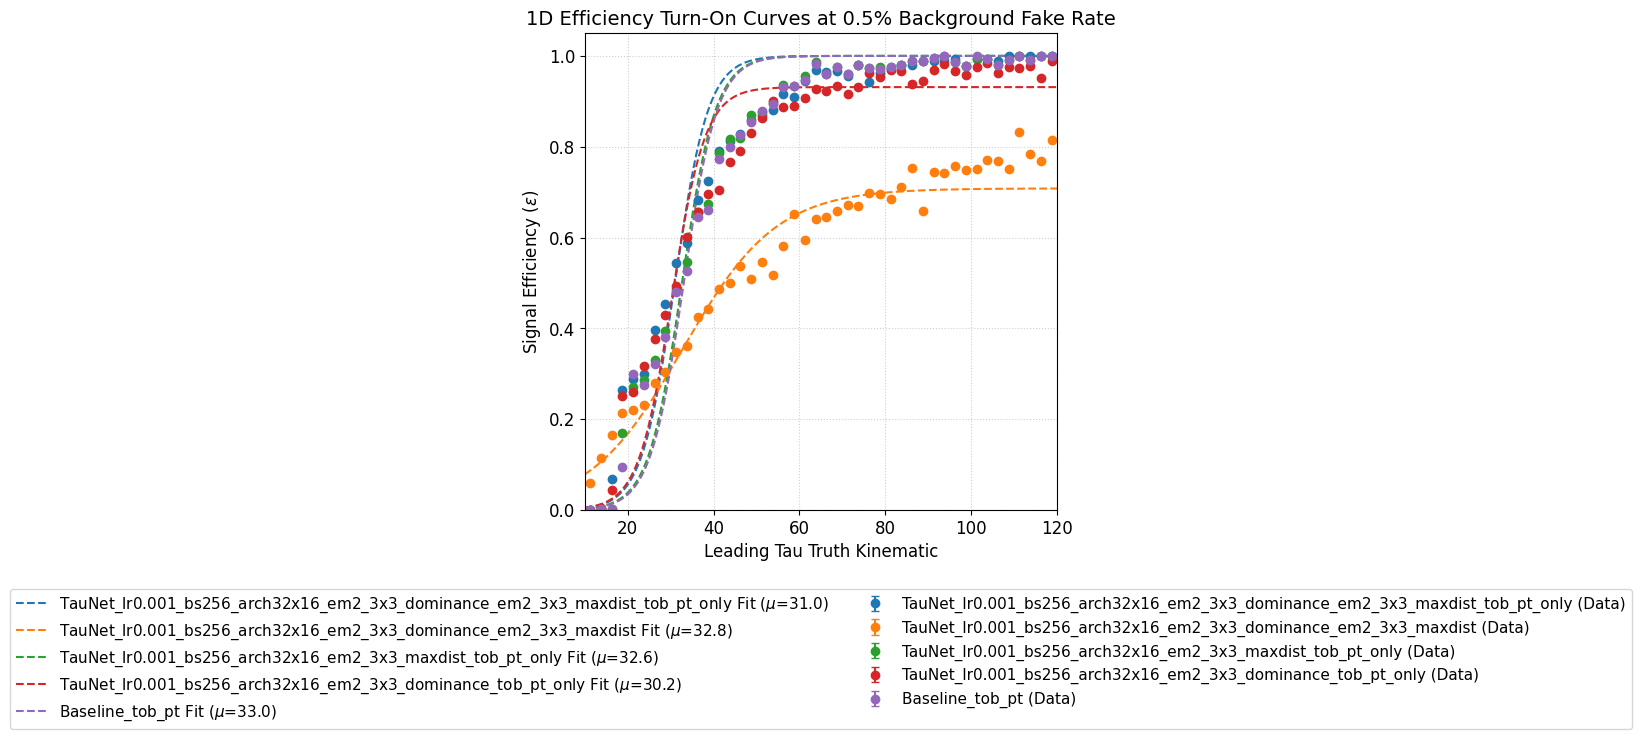

In [11]:
def fermi_dirac(x, plateau, slope, midpoint):
    return plateau / (1.0 + np.exp(-np.clip(slope * (x - midpoint), -500, 500)))

fig, ax = plt.subplots(figsize=(12, 8))

# Generate smooth x-axis values for drawing the continuous fit curves
x_smooth = np.linspace(10, 120, 500)  # Updated to match default pt_max

# Choose specific experiments to present from now on...

# by layer
include_exps_with = ['em0']
exclude_exps_with = ['em1', 'em2', 'em3', 'had']

# by feature
include_exps_with = ['dominance']
exclude_exps_with = ['sparsity', 'sum']

include_exps_with = ['em0', 'em1', 'em2', 'em3', 'had', 'core_physics', 'Baseline_tob']
exclude_exps_with = ['em2_all', 'core_physics', 'top3']

# The filter line
df_experiments = df_experiments[
    df_experiments["experiment_name"].str.contains('|'.join(include_exps_with), na=False) &
    ~df_experiments["experiment_name"].str.contains('|'.join(exclude_exps_with), na=False)
]

for _, row in df_experiments.iterrows():
    m_path = os.path.join(row['path'], "metrics.json")
    with open(m_path, 'r') as f:
        metrics = json.load(f)

    toc_data = metrics["turn_on_curve"]
    # FIX 1: Use the new "bins" key (with fallback for old files)
    eval_bins = np.array(toc_data.get("bins", toc_data.get("pt_bins")))
    bin_centers = (eval_bins[:-1] + eval_bins[1:]) / 2.0
    binned_effs = toc_data["binned_efficiencies"]

    # NEW FEATURE: Grab the errors we calculated in the new script
    binned_errs = toc_data.get("binned_errors", np.zeros_like(binned_effs))

    # Plot the data points WITH ERROR BARS
    line = ax.errorbar(bin_centers, binned_effs, yerr=binned_errs, fmt='o',
                       capsize=3, label=f"{row['experiment_name']} (Data)")

    if toc_data["fit_success"]:
        fit_params = toc_data["fermi_dirac_fit"]
        y_fit = fermi_dirac(x_smooth, fit_params["plateau"], fit_params["slope"], fit_params["midpoint"])
        ax.plot(x_smooth, y_fit, '--', color=line[0].get_color(),
                label=fr"{row['experiment_name']} Fit ($\mu$={fit_params['midpoint']:.1f})")

ax.set_xlabel("Leading Tau Truth Kinematic")
ax.set_ylabel(r"Signal Efficiency ($\epsilon$)")
ax.set_title("1D Efficiency Turn-On Curves at 0.5% Background Fake Rate")
ax.set_xlim(10, 120) # Updated limits
ax.set_ylim(0.0, 1.05)
ax.grid(True)

# Generate the legend
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
)

# Apply tight layout directly to the original figure object
# We pass a rect parameter so tight_layout doesn't crop out your dropped legend
fig.tight_layout(rect=[0, 0.03, 1, 1])

# Print the LaTeX table
latex_cols = ['experiment_name', 'fd_midpoint', 'fd_slope', 'fd_plateau']
print(df_experiments[latex_cols].to_latex(index=False, float_format="%.4f"))
print(df_experiments[latex_cols])
# Save the specific figure object directly, not the general plt state
fig.savefig('DESCRIBE_DATA_HERE.pdf', format='pdf', bbox_inches='tight')

plt.show()

\begin{tabular}{lrrr}
\toprule
experiment_name & fd_midpoint & fd_slope & fd_plateau \\
\midrule
TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist_tob_pt_only & 30.3665 & 0.2638 & 0.9534 \\
TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist & 33.9444 & 0.0873 & 0.7195 \\
TauNet_lr0.001_bs256_arch32x16_em2_3x3_maxdist_tob_pt_only & 33.2775 & 0.2472 & 1.0000 \\
TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_tob_pt_only & 30.2946 & 0.2633 & 0.9477 \\
Baseline_tob_pt & 33.0376 & 0.2557 & 1.0000 \\
\bottomrule
\end{tabular}

                                      experiment_name  fd_midpoint  fd_slope  \
0   TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominan...    30.366452  0.263844   
2   TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominan...    33.944407  0.087252   
4   TauNet_lr0.001_bs256_arch32x16_em2_3x3_maxdist...    33.277516  0.247216   
6   TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominan...    30.294646  0.263339   
10                                    Basel

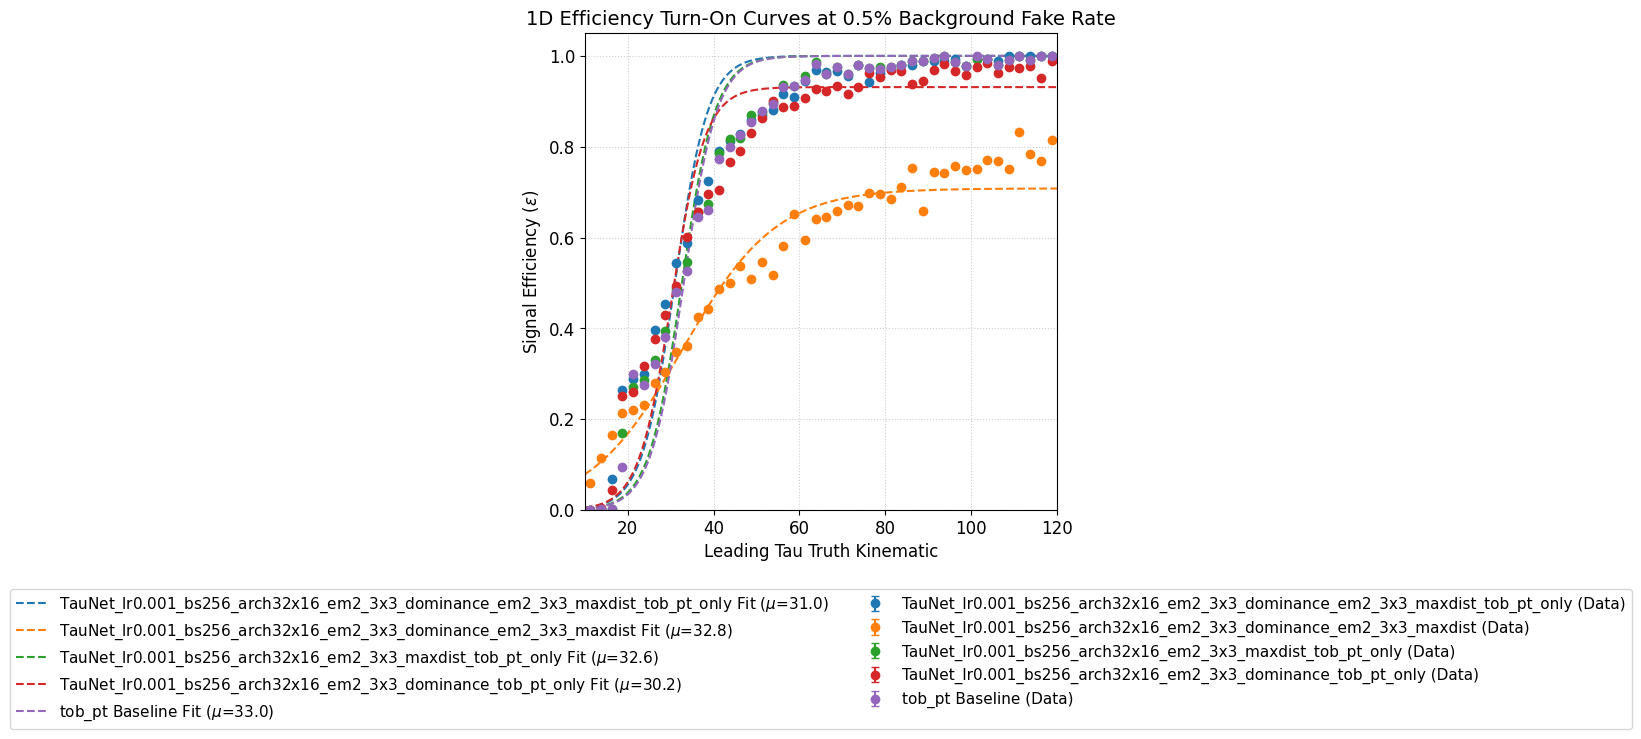

In [12]:
def fermi_dirac(x, plateau, slope, midpoint):
    return plateau / (1.0 + np.exp(-np.clip(slope * (x - midpoint), -500, 500)))

fig, ax = plt.subplots(figsize=(12, 8))

# Generate smooth x-axis values for drawing the continuous fit curves
x_smooth = np.linspace(10, 120, 500)  # Updated to match default pt_max

# Choose specific experiments to present from now on...

# by layer
include_exps_with = ['em0']
exclude_exps_with = ['em1', 'em2', 'em3', 'had']

# by feature
include_exps_with = ['dominance']
exclude_exps_with = ['sparsity', 'sum']

include_exps_with = ['em0', 'em1', 'em2', 'em3', 'had', 'core_physics', 'Baseline_tob']
exclude_exps_with = ['em2_all', 'core_physics', 'top3']

# The filter line
df_experiments = df_experiments[
    df_experiments["experiment_name"].str.contains('|'.join(include_exps_with), na=False) &
    ~df_experiments["experiment_name"].str.contains('|'.join(exclude_exps_with), na=False)
]

# --- NEW: Dictionary mapping to shorten names for the legend ---
name_mapping = {
    "Baseline_tob_pt": "tob_pt Baseline",
    "TauNet_lr0.001_bs256_em0_dominance_em0_sparsity_em0_sum": "EM0 Layer (All Features)",
    "TauNet_lr0.001_bs256_em1_dominance_em1_sparsity_em1_sum": "EM1 Layer (All Features)",
    "TauNet_lr0.001_bs256_em2_3x3_dominance_em2_3x3_sparsity_em2_3x3_sum": "EM2 Layer (All Features)",
    "TauNet_lr0.001_bs256_em3_dominance_em3_sparsity_em3_sum": "EM3 Layer (All Features)",
    "TauNet_lr0.001_bs256_had_dominance_had_sparsity_had_sum": "HAD Layer (All Features)",
    "TauNet_lr0.001_bs256_em0_dominance_em1_dominance_em2_3x3_dominance_em3_dominance_had_dominance": "All Layers (Dominance Only)",
    "TauNet_lr0.001_bs256_em0_sparsity_em1_sparsity_em2_3x3_sparsity_em3_sparsity_had_sparsity": "All Layers (Sparsity Only)",
    "TauNet_lr0.001_bs256_em0_sum_em1_sum_em2_3x3_sum_em3_sum_had_sum": "All Layers (Sum Only)",
    "TauNet_lr0.001_bs256_em0_dominance_em0_sparsity_em0_sum_em1_dominance_em1_sparsity_em1_sum_em2_3x3_dominance_em2_3x3_sparsity_em2_3x3_sum_em3_dominance_em3_sparsity_em3_sum_had_dominance_had_sparsity_had_sum": "All Layers (All Features)",
    "TauNet_lr0.001_bs256_em2_best_3x3_fraction_em2_best_3x3_fraction_em2_top3_3x3_features": "EM2 Layer (Legacy Top Features)"
}

for _, row in df_experiments.iterrows():
    m_path = os.path.join(row['path'], "metrics.json")
    with open(m_path, 'r') as f:
        metrics = json.load(f)

    toc_data = metrics["turn_on_curve"]
    # FIX 1: Use the new "bins" key (with fallback for old files)
    eval_bins = np.array(toc_data.get("bins", toc_data.get("pt_bins")))
    bin_centers = (eval_bins[:-1] + eval_bins[1:]) / 2.0
    binned_effs = toc_data["binned_efficiencies"]

    # NEW FEATURE: Grab the errors we calculated in the new script
    binned_errs = toc_data.get("binned_errors", np.zeros_like(binned_effs))

    # --- NEW: Get the clean name (falls back to original if not found) ---
    clean_name = name_mapping.get(row['experiment_name'], row['experiment_name'])

    # Plot the data points WITH ERROR BARS using clean_name
    line = ax.errorbar(bin_centers, binned_effs, yerr=binned_errs, fmt='o',
                       capsize=3, label=f"{clean_name} (Data)")

    if toc_data["fit_success"]:
        fit_params = toc_data["fermi_dirac_fit"]
        y_fit = fermi_dirac(x_smooth, fit_params["plateau"], fit_params["slope"], fit_params["midpoint"])
        # Plot the fit using clean_name
        ax.plot(x_smooth, y_fit, '--', color=line[0].get_color(),
                label=fr"{clean_name} Fit ($\mu$={fit_params['midpoint']:.1f})")

ax.set_xlabel("Leading Tau Truth Kinematic")
ax.set_ylabel(r"Signal Efficiency ($\epsilon$)")
ax.set_title("1D Efficiency Turn-On Curves at 0.5% Background Fake Rate")
ax.set_xlim(10, 120) # Updated limits
ax.set_ylim(0.0, 1.05)
ax.grid(True)

# Generate the legend
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
)

# Apply tight layout directly to the original figure object
# We pass a rect parameter so tight_layout doesn't crop out your dropped legend
fig.tight_layout(rect=[0, 0.03, 1, 1])

# Print the LaTeX table (You can also apply the mapping here if you want clean table outputs!)
latex_cols = ['experiment_name', 'fd_midpoint', 'fd_slope', 'fd_plateau']
print(df_experiments[latex_cols].to_latex(index=False, float_format="%.4f"))
print(df_experiments[latex_cols])

# Save the specific figure object directly, not the general plt state
fig.savefig('DESCRIBE_DATA_HERE.pdf', format='pdf', bbox_inches='tight')

plt.show()

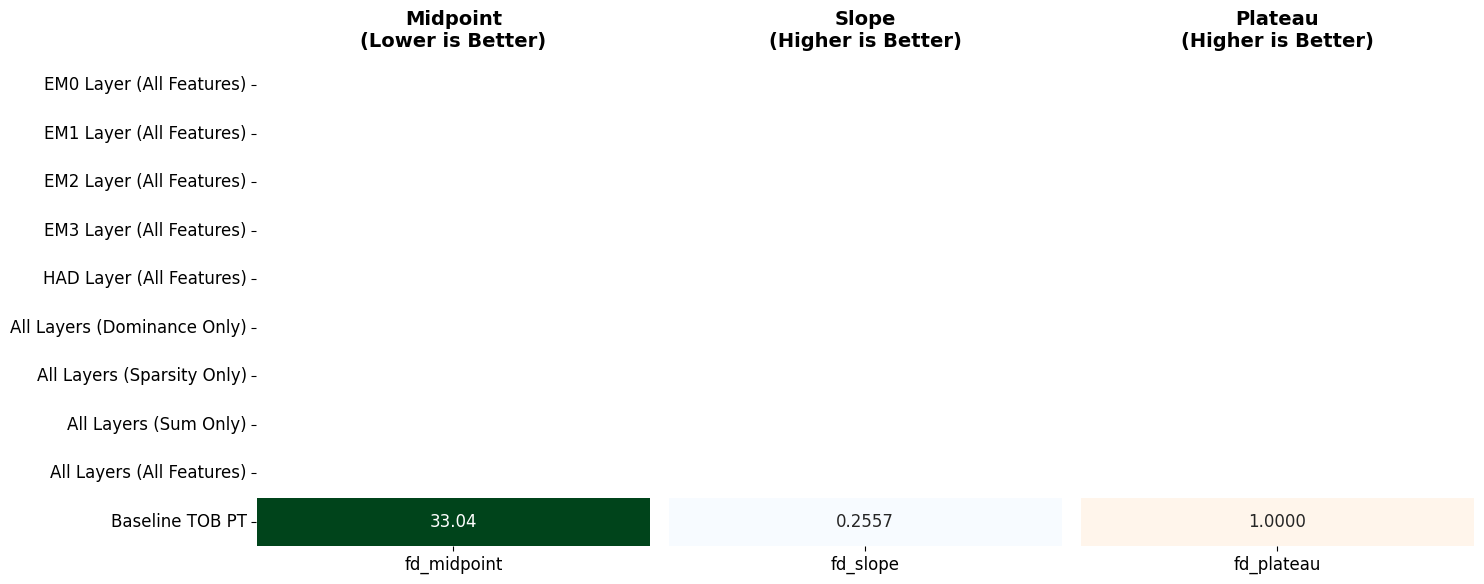

In [13]:
# HEAT MAP PRETTY PRINT FOR LATEX


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a clean mapping for your experiment names
# We group them into: Single Layers, Single Features, and the Combined model
name_mapping = {
    # Single Layer (All Features)
    "TauNet_lr0.001_bs256_em0_dominance_em0_sparsity_em0_sum": "EM0 Layer (All Features)",
    "TauNet_lr0.001_bs256_em1_dominance_em1_sparsity_em1_sum": "EM1 Layer (All Features)",
    "TauNet_lr0.001_bs256_em2_3x3_dominance_em2_3x3_sparsity_em2_3x3_sum": "EM2 Layer (All Features)",
    "TauNet_lr0.001_bs256_em3_dominance_em3_sparsity_em3_sum": "EM3 Layer (All Features)",
    "TauNet_lr0.001_bs256_had_dominance_had_sparsity_had_sum": "HAD Layer (All Features)",

    # All Layers (Single Feature)
    "TauNet_lr0.001_bs256_em0_dominance_em1_dominance_em2_3x3_dominance_em3_dominance_had_dominance": "All Layers (Dominance Only)",
    "TauNet_lr0.001_bs256_em0_sparsity_em1_sparsity_em2_3x3_sparsity_em3_sparsity_had_sparsity": "All Layers (Sparsity Only)",
    "TauNet_lr0.001_bs256_em0_sum_em1_sum_em2_3x3_sum_em3_sum_had_sum": "All Layers (Sum Only)",

    # Combined
    "TauNet_lr0.001_bs256_em0_dominance_em0_sparsity_em0_sum_em1_dominance_em1_sparsity_em1_sum_em2_3x3_dominance_em2_3x3_sparsity_em2_3x3_sum_em3_dominance_em3_sparsity_em3_sum_had_dominance_had_sparsity_had_sum": "All Layers (All Features)",

    # Baseline
    "Baseline_tob_pt" : "Baseline TOB PT"
}

# Apply mapping and set as index
df_heat = df_experiments.copy()
df_heat['Clean_Name'] = df_heat['experiment_name'].map(name_mapping)

# Drop any rows that didn't match the map (optional) and set index
df_heat = df_heat.dropna(subset=['Clean_Name']).set_index('Clean_Name')

# Define the order we want them to appear in the heatmap (top to bottom)
ordered_index = [
    "EM0 Layer (All Features)",
    "EM1 Layer (All Features)",
    "EM2 Layer (All Features)",
    "EM3 Layer (All Features)",
    "HAD Layer (All Features)",
    "All Layers (Dominance Only)",
    "All Layers (Sparsity Only)",
    "All Layers (Sum Only)",
    "All Layers (All Features)",
    "Baseline TOB PT"
]
df_heat = df_heat.reindex(ordered_index)

# 2. Plotting the 1x3 Heatmap
fig, axes = plt.subplots(1, 3, figsize=(15, 6), gridspec_kw={'width_ratios': [1, 1, 1]})

# Midpoint Heatmap (Lower is better, so we reverse the colormap: _r)
sns.heatmap(df_heat[['fd_midpoint']], annot=True, fmt=".2f", cmap="Greens_r",
            ax=axes[0], cbar=False, linewidths=0.5, linecolor='white')
axes[0].set_title("Midpoint\n(Lower is Better)", pad=10, weight='bold')
axes[0].set_ylabel("")

# Slope Heatmap (Higher is better)
sns.heatmap(df_heat[['fd_slope']], annot=True, fmt=".4f", cmap="Blues",
            ax=axes[1], cbar=False, linewidths=0.5, linecolor='white')
axes[1].set_title("Slope\n(Higher is Better)", pad=10, weight='bold')
axes[1].set_ylabel("")
axes[1].set_yticks([]) # Hide y-axis labels for the middle plot so it's not cluttered

# Plateau Heatmap (Higher is better)
sns.heatmap(df_heat[['fd_plateau']], annot=True, fmt=".4f", cmap="Oranges",
            ax=axes[2], cbar=False, linewidths=0.5, linecolor='white')
axes[2].set_title("Plateau\n(Higher is Better)", pad=10, weight='bold')
axes[2].set_ylabel("")
axes[2].set_yticks([]) # Hide y-axis labels for the right plot

# Adjust layout and save
fig.tight_layout()
fig.savefig('DESCRIBE HEATMAP HERE.pdf', format='pdf', bbox_inches='tight')
plt.show()

## Nice visualization for above result

In [14]:
# --- INTERACTIVE TURN-ON CURVE VIEWER ---
# Run this after Cell 6 to explore the data dynamically.
import plotly.graph_objects as go

fig_interactive = go.Figure()

for _, row in df_experiments.iterrows():
    m_path = os.path.join(row['path'], "metrics.json")
    with open(m_path, 'r') as f:
        metrics = json.load(f)

    toc_data = metrics["turn_on_curve"]
    eval_bins = np.array(toc_data.get("bins", toc_data.get("pt_bins")))
    bin_centers = (eval_bins[:-1] + eval_bins[1:]) / 2.0
    binned_effs = toc_data["binned_efficiencies"]
    binned_errs = toc_data.get("binned_errors", np.zeros_like(binned_effs))

    exp_name = row['experiment_name']

    # Data Points
    fig_interactive.add_trace(go.Scatter(
        x=bin_centers, y=binned_effs, mode='markers',
        error_y=dict(type='data', array=binned_errs, visible=True, thickness=2),
        name=f"{exp_name} (Data)", legendgroup=exp_name, marker=dict(size=8)
    ))

    # Fit Line
    if toc_data["fit_success"]:
        fit_params = toc_data["fermi_dirac_fit"]
        y_fit = fermi_dirac(x_smooth, fit_params["plateau"], fit_params["slope"], fit_params["midpoint"])
        fig_interactive.add_trace(go.Scatter(
            x=x_smooth, y=y_fit, mode='lines', line=dict(dash='dash'),
            name=f"{exp_name} Fit (μ={fit_params['midpoint']:.1f})", legendgroup=exp_name
        ))

fig_interactive.update_layout(
    title="Interactive 1D Efficiency Turn-On Curves (Click legend to toggle)",
    xaxis_title="Leading Tau Truth Kinematic", yaxis_title="Signal Efficiency (ε)",
    xaxis=dict(range=[10, 120]), yaxis=dict(range=[0.0, 1.05]),
    hovermode="x unified", template="plotly_white", height=600
)

fig_interactive.update_layout(
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.2, # Pushes the legend below the x-axis
        xanchor="center",
        x=0.5
    )
)

fig_interactive.update_layout(
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-10, # Pushes the legend below the x-axis
        xanchor="center",
        x=0.5
    )
)

fig_interactive.update_layout(
    legend=dict(font=dict(size=10)) # Reduce font size
)
# fig_interactive.update_layout(showlegend=False)

fig_interactive.show()

## Deep Dive: Neural Network vs. Baseline Kinematics
This section performs a direct, event-by-event comparison between the Neural Network trigger efficiencies and the baseline standard (triggering purely on `tob_pt`). It utilizes a two-panel layout to clearly display the absolute efficiency gain ($\Delta\epsilon$) in the lower residuals graph.

Plotting STATIC graph for the 4 most recent unique models...


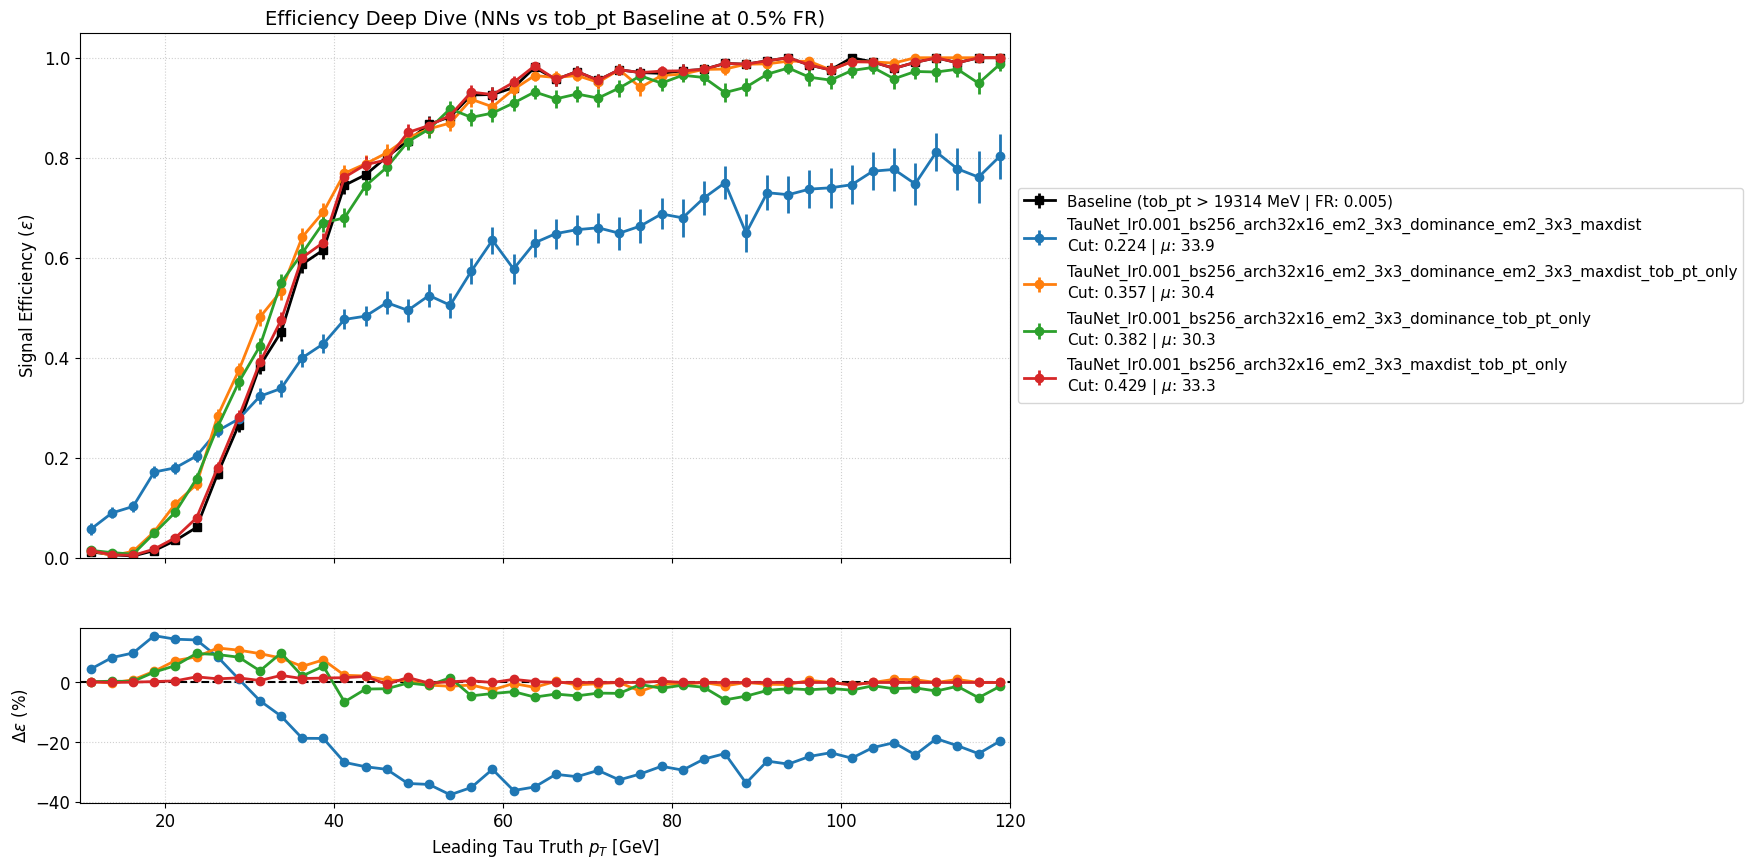

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

def CalcThresh(DF, Criteria, FakeRate, objects=2):
    DF = DF.copy()
    MaxVal = np.max(DF[Criteria].values)
    DF[Criteria] /= MaxVal
    DF["signal"] = 0
    powers = 15
    threshold = 0.5
    for i in range(2, powers):
        TempDF = DF.copy()
        TempDF.loc[TempDF[Criteria] > threshold, "signal"] = 1
        TempDF = TempDF.groupby("eventNumber").sum().reset_index(drop=True)
        Denom = float(TempDF.shape[0])
        Numer = (TempDF["signal"] >= objects).sum()
        ratio = Numer / Denom
        if ratio > FakeRate:
            threshold += np.power(0.5, i)
        else:
            threshold -= np.power(0.5, i)
    return threshold * MaxVal, ratio

def MakeTOC(DF, minval, maxval, bins, Criteria, FakeRate, x_bins="truth_pt"):
    Threshold, ratio = CalcThresh(DF[DF["Type"] == "BKG"].copy(), Criteria, FakeRate)
    SignalDF = DF[DF["signal"] == 1].copy()
    Vector = SignalDF[x_bins].values
    x = np.linspace(minval, maxval, bins + 1)
    x = 0.5 * (x[1:] + x[:-1])
    diff = 0.5 * np.diff(x)[0]
    y = np.zeros(x.shape)
    dy = np.zeros(x.shape)
    for i in range(x.size):
        Inds = abs(Vector - x[i]) <= diff
        TempDF = SignalDF.iloc[Inds]
        Denom = TempDF.shape[0]
        Numer = TempDF[TempDF[Criteria] > Threshold].shape[0]
        if Denom > 0:
            y[i] = Numer / float(Denom)
            dy[i] = np.sqrt(y[i] * (1 - y[i]) / Denom)
    return x, y, dy, Threshold, ratio

def plot_deep_dive_comparison(df_experiments, models_to_compare, target_nn_fr=0.005):
    runs_to_plot = df_experiments[df_experiments['experiment_name'].isin(models_to_compare)]
    if runs_to_plot.empty:
        print("No matching models found.")
        return

    fig, (ax_main, ax_res) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    # Load baseline from the legacy CSV of the first valid model to get the physical properties
    base_path = os.path.join(runs_to_plot.iloc[0]['path'], "predictions.parquet")
    df_base = pd.read_parquet(base_path)

    # Calculate exact baseline from TOC_1D logic
    x_base, y_base, dy_base, r3thresh, r3ratio = MakeTOC(
        df_base, 10000, 120000, 44, "tob_pt", target_nn_fr, x_bins="truth_pt"
    )
    x_base_gev = x_base / 1000.0 # Convert to GeV for plot

    ax_main.errorbar(x_base_gev, y_base, yerr=dy_base, fmt='ks-', linewidth=2,
                     label=f"Baseline (tob_pt > {round(r3thresh)} MeV | FR: {np.around(r3ratio, 4)})")
    ax_res.axhline(0, color='black', linestyle='--', linewidth=1.5)

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for idx, (_, row) in enumerate(runs_to_plot.iterrows()):
        df_run = pd.read_parquet(os.path.join(row['path'], "predictions.parquet"))

        # Calculate exactly via MakeTOC
        x_nn, y_nn, dy_nn, nn_thresh, nn_ratio = MakeTOC(
            df_run, 10000, 120000, 44, "nn_score", target_nn_fr, x_bins="truth_pt"
        )

        color = colors[idx % len(colors)]
        label_str = f"{row['experiment_name']}\nCut: {nn_thresh:.3f} | $\\mu$: {row['fd_midpoint']:.1f}"

        ax_main.errorbar(x_base_gev, y_nn, yerr=dy_nn, fmt='o-', color=color, linewidth=2, label=label_str)
        residuals = (y_nn - y_base) * 100
        ax_res.plot(x_base_gev, residuals, 'o-', color=color, linewidth=2)

    ax_main.set_ylabel(r"Signal Efficiency ($\epsilon$)")
    ax_main.set_title(f"Efficiency Deep Dive (NNs vs tob_pt Baseline at {target_nn_fr*100:.1f}% FR)")
    ax_main.set_xlim(10, 120)
    ax_main.set_ylim(0.0, 1.05)
    ax_main.grid(True, linestyle=':')
    # ax_main.legend(loc="lower right", frameon=True, fontsize=10)
    ax_main.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    plt.setp(ax_main.get_xticklabels(), visible=False)

    ax_res.set_xlabel("Leading Tau Truth $p_T$ [GeV]")
    ax_res.set_ylabel(r"$\Delta\epsilon$ (%)")
    ax_res.grid(True, linestyle=':')
    plt.show()

# --- Execution ---
if 'df_experiments' in locals() and not df_experiments.empty:
    # 1. Sort chronologically by folder name (run_id)
    # 2. Keep only the last (most recent) entry for each experiment_name
    df_experiments = df_experiments[df_experiments['run_id'] != 'run_0_baseline_tob_pt'].reset_index(drop=True)
    df_latest_runs = df_experiments.sort_values('run_id').drop_duplicates(subset='experiment_name', keep='last')

    # Extract all unique model names
    models_to_compare = df_latest_runs['experiment_name'].tolist()

    print(f"Plotting STATIC graph for the {len(models_to_compare)} most recent unique models...")

    # Call the STATIC matplotlib function defined in this cell
    plot_deep_dive_comparison(df_latest_runs, models_to_compare)
else:
    print("Please run the earlier cells to load df_experiments first.")

In [16]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def show_interactive_deep_dive(df_experiments, models_to_compare, target_nn_fr=0.005):
    runs_to_plot = df_experiments[df_experiments['experiment_name'].isin(models_to_compare)]
    if runs_to_plot.empty:
        return

    fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.05, row_heights=[0.75, 0.25])

    # Dynamic Baseline calculation
    base_path = os.path.join(runs_to_plot.iloc[0]['path'], "predictions.parquet")
    df_base = pd.read_parquet(base_path)

    x_base, y_base, dy_base, r3thresh, r3ratio = MakeTOC(
        df_base, 10000, 120000, 44, "tob_pt", target_nn_fr, x_bins="truth_pt"
    )
    x_base_gev = x_base / 1000.0

    # Baseline Plot
    fig.add_trace(go.Scatter(
        x=x_base_gev, y=y_base, mode='lines+markers', name=f"Baseline (tob_pt > {round(r3thresh)} MeV)",
        line=dict(color='black', width=2), marker=dict(symbol='square')
    ), row=1, col=1)

    # Baseline Residual Reference Line (Zero line)
    fig.add_trace(go.Scatter(
        x=[10, 120], y=[0, 0], mode='lines', showlegend=False, line=dict(color='black', dash='dash')
    ), row=2, col=1)

    # Standard Plotly color palette for iterating over NNs
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

    # Plot Models
    for idx, (_, row) in enumerate(runs_to_plot.iterrows()):
        df_run = pd.read_parquet(os.path.join(row['path'], "predictions.parquet"))

        x_nn, y_nn, dy_nn, nn_thresh, nn_ratio = MakeTOC(
            df_run, 10000, 120000, 44, "nn_score", target_nn_fr, x_bins="truth_pt"
        )

        label_str = f"{row['experiment_name']} (Cut: {nn_thresh:.3f})"
        color = colors[idx % len(colors)]

        # Main NN Trace
        fig.add_trace(go.Scatter(
            x=x_base_gev, y=y_nn, mode='lines+markers',
            name=label_str,
            legendgroup=label_str,       # <-- Syncs the legend show/hide toggle
            line=dict(color=color),      # <-- Forces identical color as the residual
            error_y=dict(type='data', array=dy_nn, visible=True)
        ), row=1, col=1)

        # Residual Trace
        residuals = (y_nn - y_base) * 100
        fig.add_trace(go.Scatter(
            x=x_base_gev, y=residuals, mode='lines+markers',
            showlegend=False,
            legendgroup=label_str,       # <-- Syncs the legend show/hide toggle
            line=dict(color=color)       # <-- Forces identical color as the main trace
        ), row=2, col=1)

    fig.update_layout(title="Interactive Efficiency Deep Dive", template="plotly_white", height=800, hovermode="x unified")
    fig.update_yaxes(title_text="Signal Efficiency (ε)", range=[0.0, 1.05], row=1, col=1)
    fig.update_yaxes(title_text="Δε (%)", row=2, col=1)
    fig.update_xaxes(title_text="Leading Tau Truth pT [GeV]", range=[10, 120], row=2, col=1)
    fig.update_layout(
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=-0.2, # Pushes the legend below the x-axis
            xanchor="center",
            x=0.5
        )
    )

    fig.update_layout(
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=-10, # Pushes the legend below the x-axis
            xanchor="center",
            x=0.5
        )
    )

    fig.update_layout(
        legend=dict(font=dict(size=10)) # Reduce font size
    )
    fig.show()

# --- Execution ---
if 'df_experiments' in locals() and not df_experiments.empty:
    # 1. Sort chronologically by folder name (run_id)
    # 2. Keep only the last (most recent) entry for each experiment_name
    df_latest_runs = df_experiments.sort_values('run_id').drop_duplicates(subset='experiment_name', keep='last')

    # Extract all unique model names
    models_to_compare = df_latest_runs['experiment_name'].tolist()

    print(f"Plotting INTERACTIVE graph")

    # Call the INTERACTIVE plotly function defined in this cell
    show_interactive_deep_dive(df_latest_runs, models_to_compare)
else:
    print("Please run the earlier cells to load df_experiments first.")

Plotting INTERACTIVE graph
